In [1]:
%pip install py-readability-metrics

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

psalms = pd.read_csv("../data/grouped_psalm.csv")
psalms

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...
...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio..."
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ..."


# Flesch-Kincaid Readability Tests

In [3]:
from readability import Readability

def get_fk_score(text):
    # Ensure it's a valid string and not empty
    if not isinstance(text, str) or not text.strip():
        return None
    try:
        r = Readability(text)
        return r.flesch_kincaid().score
    except Exception:
        # Handles cases where a verse is too short to analyze
        return None

# Create a new column in your DataFrame with the scores
psalms['fk_score'] = psalms['verse'].apply(get_fk_score)

print(psalms[['verse', 'fk_score']].head())

                                               verse   fk_score
0  Blessed is the man Who walks not in the counse...  49.677820
1  Why do the nations rage And the people meditat...  75.150603
2  A psalm by David when he fled from the face of...  55.884667
3  For the End in psalms an ode by David You hear...  61.126970
4  For the End concerning the inheritance a psalm...  93.637903


In [4]:
psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,fk_score
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,49.677820
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,75.150603
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,55.884667
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,61.126970
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,93.637903
...,...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...,7.597561
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio...",5.102931
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...,7.344203
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ...",8.245791


In [5]:
display(psalms[psalms['fk_score'].isna()])

print(
    f"\nNumber of Missing Scores due to length of Psalm: "
    f"{psalms['fk_score'].isna().sum()}"
)

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,fk_score
98,98,Orthodox,Bible,99,A psalm of thanksgiving Shout aloud to the Lor...,psalm thanksgiving shout aloud lord earth serv...,NaN
115,115,Orthodox,Bible,116,Alleluia Praise the Lord all you Gentiles Prai...,alleluia praise lord gentile praise people mer...,NaN
121,121,Orthodox,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,onean ode ascent ilift eye whodwell heaven beh...,NaN
124,124,Orthodox,Bible,125,1An ode of ascents When the Lord returned the ...,onean ode ascent lord returned captive zion be...,NaN
129,129,Orthodox,Bible,130,1An ode of ascents by David OLord My heart is ...,onean ode ascent david olord heart exalted nei...,NaN
131,131,Orthodox,Bible,132,1An ode of ascents by David Behold now what is...,onean ode ascent david behold good pleasant br...,NaN
132,132,Orthodox,Bible,133,1An ode of ascents Behold now bless the Lord A...,onean ode ascent behold bless lord servant lor...,NaN
149,149,Orthodox,Bible,150,1Alleluia Praise God in His saints Praise Him ...,onealleluia praise god saint praise firmament ...,NaN
242,242,Orthodox,Psalter,92,"The Lord reigneth, He is clothed with majesty;...","lord reigneth , clothed majesty ; lord clothed...",NaN
249,249,Orthodox,Psalter,99,"Shout with jubilation unto God, all the earth;...","shout jubilation unto god , earth ; serve lord...",NaN



Number of Missing Scores due to length of Psalm: 19


### Bible vs. Psalter

In [6]:
pd.pivot_table(data=psalms, 
               index=['text'],
               values=['fk_score'],
               aggfunc=['mean']
              )

,mean
,fk_score
text,
Bible,113.607374
Psalter,6.305709


# Gunning Fog Index

In [7]:
%pip install textstat

Note: you may need to restart the kernel to use updated packages.


In [8]:
import textstat

def get_gf_score(text):
    # Ensure it's a valid string and not empty
    if not isinstance(text, str) or not text.strip():
        return None
    try:
        return textstat.gunning_fog(text)
    except Exception:
        # Handles cases where a verse is too short to analyze
        return None

# Create a new column in your DataFrame with the scores
psalms['gf_score'] = psalms['verse'].apply(get_gf_score)

print(psalms[['verse', 'gf_score']].head())

                                               verse    gf_score
0  Blessed is the man Who walks not in the counse...   55.606015
1  Why do the nations rage And the people meditat...   81.610050
2  A psalm by David when he fled from the face of...   61.600000
3  For the End in psalms an ode by David You hear...   66.969697
4  For the End concerning the inheritance a psalm...  101.458065


In [9]:
psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,fk_score,gf_score
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,49.677820,55.606015
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,75.150603,81.610050
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,55.884667,61.600000
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,61.126970,66.969697
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,93.637903,101.458065
...,...,...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...,7.597561,9.419512
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio...",5.102931,6.552381
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...,7.344203,10.359420
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ...",8.245791,10.885158


In [10]:
psalms[psalms['gf_score'].isna()]

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,fk_score,gf_score


### Bible vs. Psalter

In [11]:
pd.pivot_table(data=psalms, 
               index=['text'],
               values=['gf_score'],
               aggfunc=['mean']
              )

,mean
,gf_score
text,
Bible,117.160507
Psalter,8.771692


# SMOG

*From the Paper:* [A New Readability Formula](https://docs.clickhelp.com/articles/clickhelp-user-manual/smog-index)

***Range of Possible Scores***: 
| Readability Score | School Level | Student Age Range | Notes |
|------------------|--------------|------------------|-------|
| 0–1 | Pre-kindergarten – 1st Grade | 3–7 | Basic level for those who are just learning to read books. |
| 1–5 | 1st Grade – 5th Grade | 7–11 | Very easy to read. |
| 5–8 | 5th Grade – 8th Grade | 11–14 | A text is considered ideal for average readers. |
| 8–11 | 8th Grade – 11th Grade | 14–17 | Fairly difficult to read. |
| 11 and above | 11th Grade – College | 17 and above | Too difficult to read for the majority of readers. |

In [12]:
import textstat

def get_smog_score(text):
    # Ensure it's a valid string and not empty
    if not isinstance(text, str) or not text.strip():
        return None
    try:
        return textstat.smog_index(text)
    except Exception:
        # Handles cases where a verse is too short to analyze
        return None

# Create a new column in your DataFrame with the scores
psalms['smog_score'] = psalms['verse'].apply(get_smog_score)

print(psalms[['verse', 'smog_score']].head())

                                               verse  smog_score
0  Blessed is the man Who walks not in the counse...   19.287187
1  Why do the nations rage And the people meditat...   22.918634
2  A psalm by David when he fled from the face of...   18.243606
3  For the End in psalms an ode by David You hear...   14.554593
4  For the End concerning the inheritance a psalm...   24.504239


In [13]:
psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,fk_score,gf_score,smog_score
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,49.677820,55.606015,19.287187
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,75.150603,81.610050,22.918634
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,55.884667,61.600000,18.243606
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,61.126970,66.969697,14.554593
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,93.637903,101.458065,24.504239
...,...,...,...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...,7.597561,9.419512,8.472885
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio...",5.102931,6.552381,6.937598
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...,7.344203,10.359420,7.793538
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ...",8.245791,10.885158,8.841846


In [14]:
psalms[psalms['smog_score'].isna()]

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,fk_score,gf_score,smog_score


### Bible vs. Psalter

In [15]:
pd.pivot_table(data=psalms, 
               index=['text'],
               values=['smog_score'],
               aggfunc=['mean']
              )

,mean
,smog_score
text,
Bible,24.533460
Psalter,8.322393


# Overall 

In [16]:
pd.pivot_table(data=psalms, 
               index=['text'],
               values=['fk_score', 'gf_score', 'smog_score'],
               aggfunc=['mean']
              )

mean                       
           fk_score    gf_score smog_score
text                                      
Bible    113.607374  117.160507  24.533460
Psalter    6.305709    8.771692   8.322393

## Using just the grouped psalms 

| Text    | FK Score | GF Score | SMOG Score |
|----------|---------:|---------:|-----------:|
| Bible   | 113.607374 | 117.160507 | 24.533460 |
| Psalter | 6.305709   | 8.771692   | 8.322393  |


There seems to be an issue with the data of the Psalms. I think this has to do with the lack of indicated sentences within the Bible Psalms data itself. The sentence breaks were probaly lost at some point during the cleaning lets fix that. 

## Rebuilding the Data

In [17]:
psalm_verses = pd.read_csv("../data/cleaned_psalm_verses.csv")
psalm_verses

,tradition,text,psalm_num,verse_num,verse
0,Orthodox,Bible,1,1,Blessed is the man Who walks not in the counse...
1,Orthodox,Bible,1,2,But his will is in the law of the Lord And in ...
2,Orthodox,Bible,1,3,He shall be like a tree Planted by streams of ...
3,Orthodox,Bible,1,4,Not so are the ungodly not so But they are lik...
4,Orthodox,Bible,1,5,Therefore the ungodly shall not rise in the ju...
...,...,...,...,...,...
4937,Orthodox,Psalter,150,1,Praise God in His holy ones; praise Him in the...
4938,Orthodox,Psalter,150,2,Praise Him for His mighty acts; praise Him acc...
4939,Orthodox,Psalter,150,3,Praise Him with the sound of the trumpet; prai...
4940,Orthodox,Psalter,150,4,Praise Him with the timbrel and dance; praise ...


In [18]:
full_psalms = (
    psalm_verses.sort_values(["text", "psalm_num", "verse_num"])
      .groupby(["tradition", "text", "psalm_num"])["verse"]
      .apply(lambda x: ". ".join(x.astype(str)) + ".")
      .reset_index()
)
# full_psalms

There were duoble periods, `..`, that were affecting the Fleshkincaid Score

In [19]:
full_psalms['verse'] = full_psalms['verse'].str.replace("..", ". ", regex=False)


In [20]:
full_psalms[full_psalms['verse'].str.contains(". .", regex=False)]

,tradition,text,psalm_num,verse


In [21]:
full_psalms['fk_score'] = full_psalms['verse'].apply(get_fk_score)
full_psalms['gf_score'] = full_psalms['verse'].apply(get_gf_score)
full_psalms['smog_score'] = full_psalms['verse'].apply(get_smog_score)
full_psalms

,tradition,text,psalm_num,verse,fk_score,gf_score,smog_score
0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,7.561153,11.272682,9.725611
1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,5.832270,8.643384,8.841846
2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,6.009667,9.100000,8.472885
3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,6.264470,9.219697,7.168622
4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,7.251237,10.524731,9.299571
...,...,...,...,...,...,...,...
296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,6.039561,7.779512,7.908726
297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...",5.102931,6.552381,6.937598
298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,3.520453,6.679420,6.742158
299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...",5.353569,7.840714,7.793538


In [22]:
pd.pivot_table(data=full_psalms, 
               index=['text'],
               values=['fk_score', 'gf_score', 'smog_score'],
               aggfunc=['mean']
              )

mean                     
         fk_score  gf_score smog_score
text                                  
Bible    6.611699  9.380564   8.733908
Psalter  6.016651  8.493506   8.219846

The lack of sentence strucutre within the data seemed to be the reason for the rfesults we got before with the outliers from the Bible Psalms.

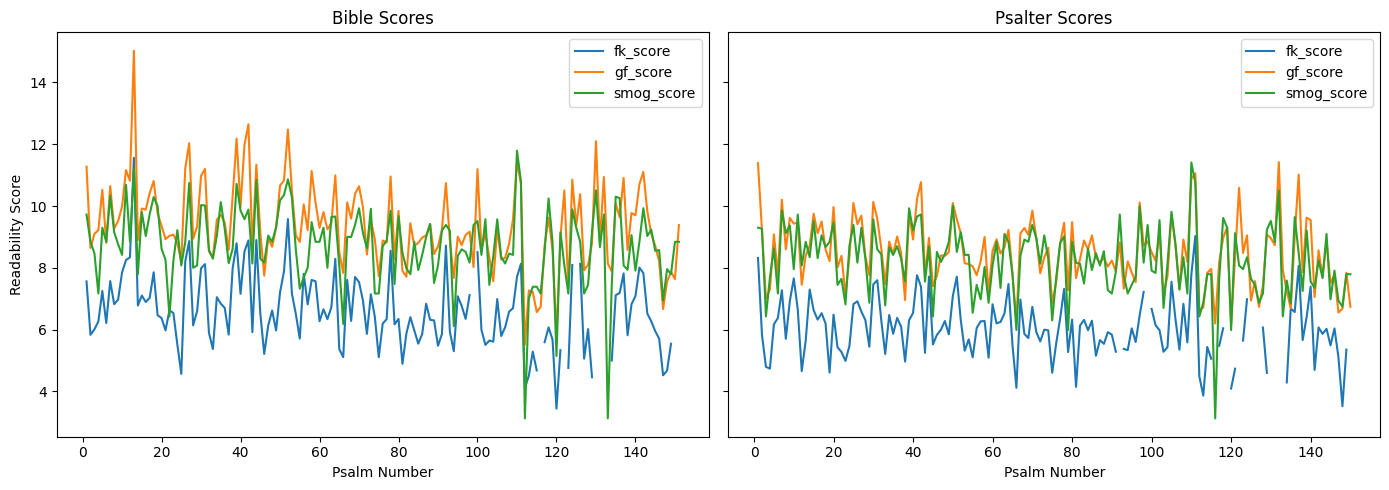

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, text in zip(axes, full_psalms['text'].unique()):
    data = full_psalms[full_psalms['text'] == text]

    data.plot(
        x='psalm_num',
        y=['fk_score', 'gf_score', 'smog_score'],
        ax=ax
    )

    ax.set_title(f"{text} Scores")
    ax.set_xlabel("Psalm Number")
    ax.set_ylabel("Readability Score")

plt.tight_layout()
plt.show()

In [24]:
print(
    full_psalms[['psalm_num', 'text', 'fk_score', 'gf_score', 'smog_score']]
    .sample(10, random_state=42)
)

     psalm_num     text  fk_score  gf_score  smog_score
177         27  Psalter  6.582662  9.687362    9.299571
289        139  Psalter  6.410966  9.624322    9.210783
228         78  Psalter  7.316873  9.456897    9.017664
198         48  Psalter  6.278791  8.389788    8.438072
60          61    Bible  6.659253  9.802299    9.299571
9           10    Bible  7.853523  9.986693    8.418075
118        119    Bible  5.680476  8.573669    8.841846
154          4  Psalter  4.739495  7.299567    7.686295
164         14  Psalter  7.297451  8.713531    8.344100
33          34    Bible  7.049675  9.555288    9.042354


### Computing the length of Psalsm for Further Analyses

In [25]:
def psalm_length(psalm):
    words = psalm.split()
    total = 0
    for word in words:
        total += len(word)
    return len(words), total/(len(words))


In [26]:
full_psalms[['word_count', 'avg_word_len']] = (
    full_psalms['verse']
    .apply(psalm_length)
    .apply(pd.Series)
)
full_psalms

,tradition,text,psalm_num,verse,fk_score,gf_score,smog_score,word_count,avg_word_len
0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,7.561153,11.272682,9.725611,133.0,3.962406
1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,5.832270,8.643384,8.841846,199.0,4.190955
2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,6.009667,9.100000,8.472885,150.0,3.766667
3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,6.264470,9.219697,7.168622,165.0,3.806061
4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,7.251237,10.524731,9.299571,248.0,4.096774
...,...,...,...,...,...,...,...,...,...
296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,6.039561,7.779512,7.908726,164.0,4.402439
297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...",5.102931,6.552381,6.937598,126.0,4.484127
298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,3.520453,6.679420,6.742158,207.0,4.318841
299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...",5.353569,7.840714,7.793538,137.0,4.430657


In [27]:
pd.pivot_table(data=full_psalms, 
               index=['text'],
               values=['fk_score', 'gf_score', 'smog_score', 'word_count', 'avg_word_len'],
               aggfunc=['mean']
              )

mean                                           
        avg_word_len  fk_score  gf_score smog_score  word_count
text                                                           
Bible       4.093512  6.611699  9.380564   8.733908  287.867550
Psalter     4.215148  6.016651  8.493506   8.219846  291.586667

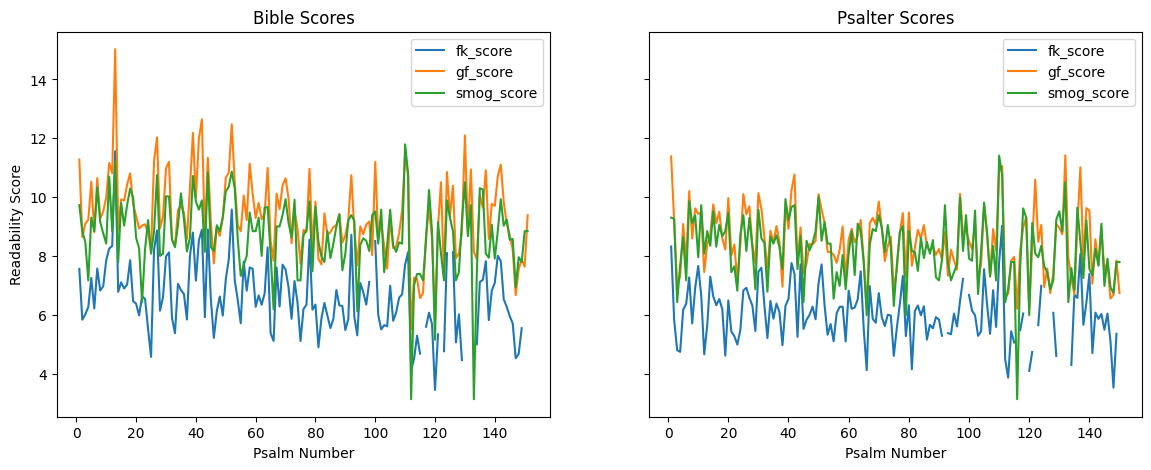

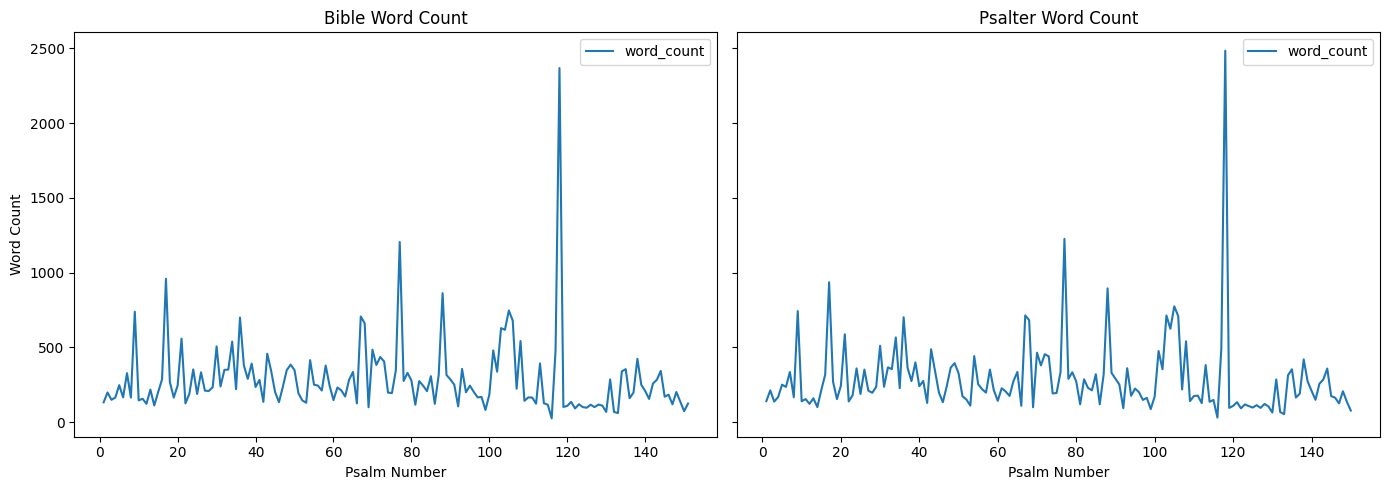

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, text in zip(axes, full_psalms['text'].unique()):
    data = full_psalms[full_psalms['text'] == text]

    data.plot(
        x='psalm_num',
        y=['fk_score', 'gf_score', 'smog_score'],
        ax=ax
    )

    ax.set_title(f"{text} Scores")
    ax.set_xlabel("Psalm Number")
    ax.set_ylabel("Readability Score")
    
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, text in zip(axes, full_psalms['text'].unique()):
    data = full_psalms[full_psalms['text'] == text]

    data.plot(
        x='psalm_num',
        y=['word_count'],
        ax=ax
    )

    ax.set_title(f"{text} Word Count")
    ax.set_xlabel("Psalm Number")
    ax.set_ylabel("Word Count")

plt.tight_layout()
plt.show()

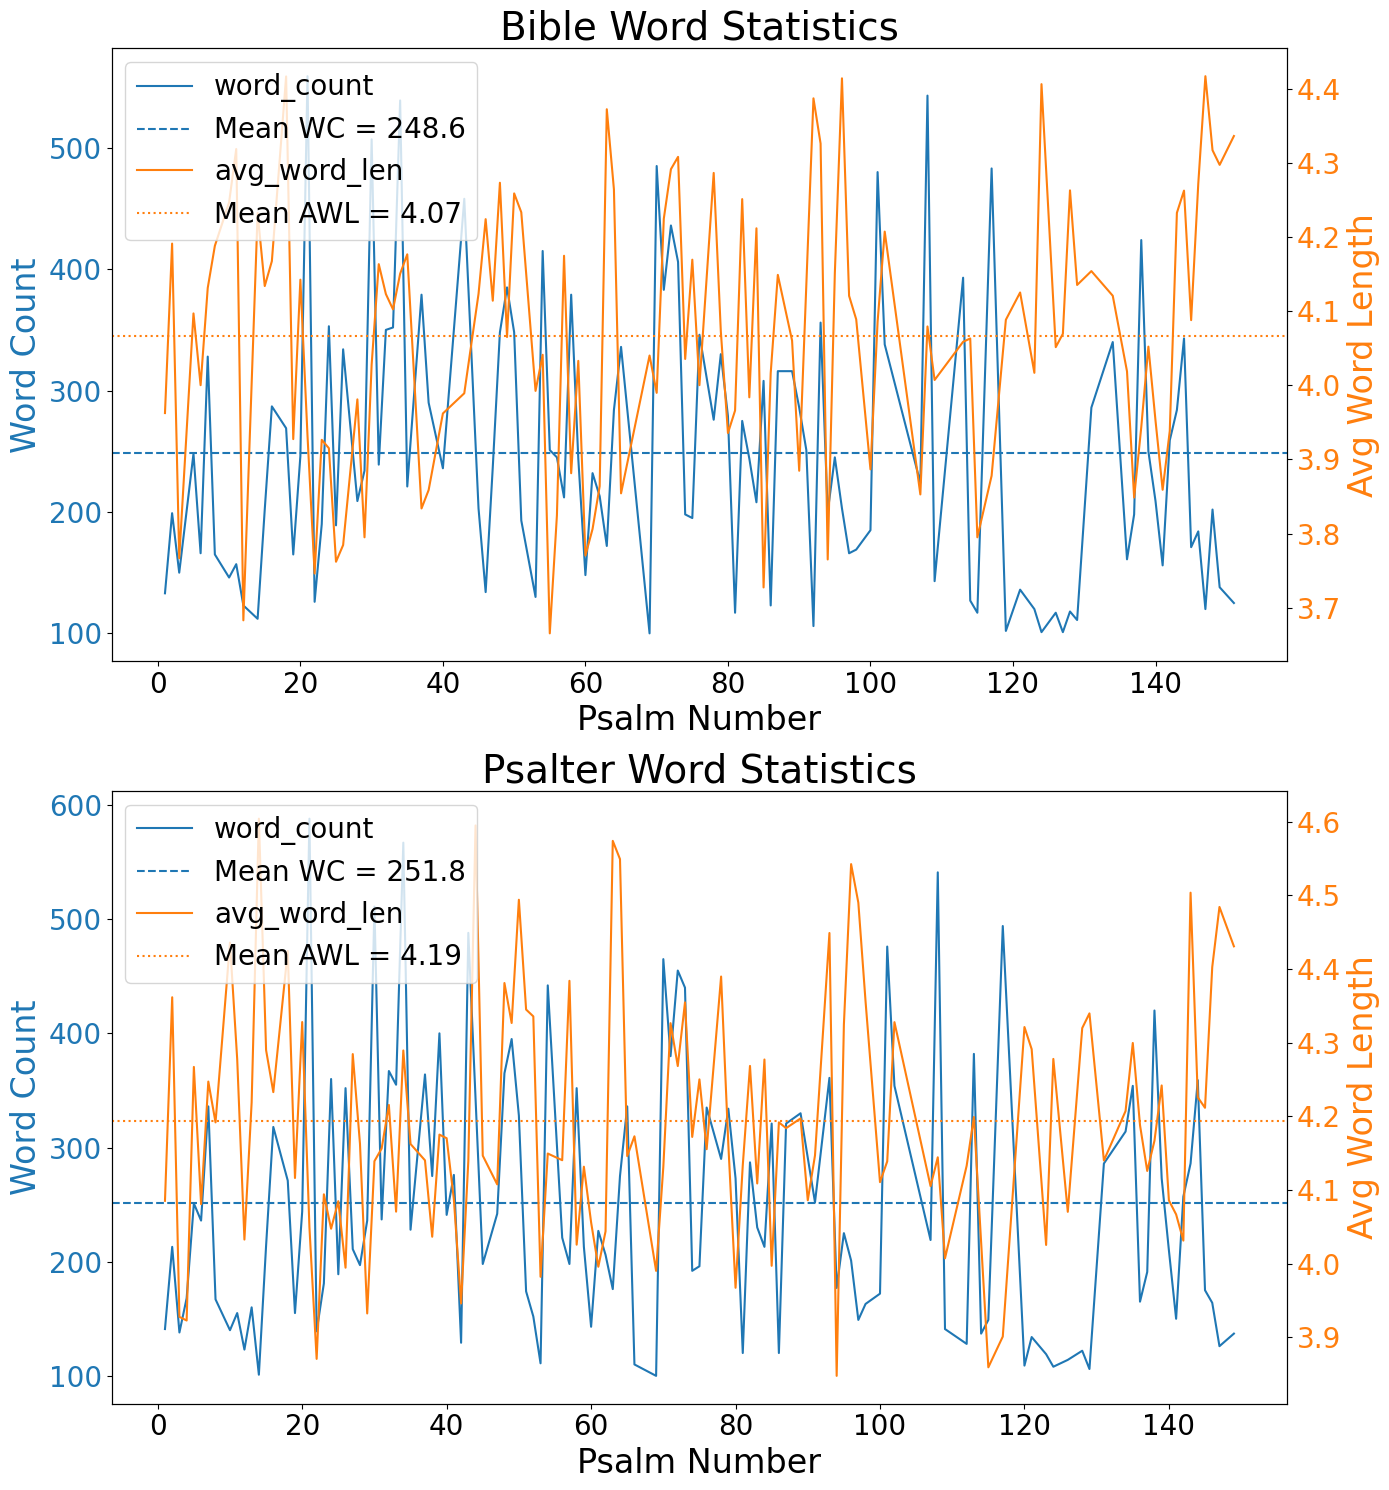

In [46]:
fig, axes = plt.subplots(2,1, figsize=(14, 15), sharey=False)

for ax, text in zip(axes, full_psalms['text'].unique()):
    data = full_psalms[full_psalms['text'] == text]

    # 1. Plot Word Count on the primary (left) y-axis
    data.plot(x='psalm_num', y='word_count', ax=ax, color='tab:blue')
    ax.set_ylabel("Word Count", color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')

    # 2. Create the secondary (right) y-axis for Average Word Length
    ax2 = ax.twinx()
    data.plot(x='psalm_num', y='avg_word_len', ax=ax2, color='tab:orange')
    ax2.set_ylabel("Avg Word Length", color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    # Calculate Means
    mean_wc = data['word_count'].mean()
    mean_awl = data['avg_word_len'].mean()

    # 3. Add horizontal lines to their respective axes
    ax.axhline(mean_wc, color='tab:blue', linestyle='--', label=f'Mean WC = {mean_wc:.1f}')
    ax2.axhline(mean_awl, color='tab:orange', linestyle=':', label=f'Mean AWL = {mean_awl:.2f}')

    # 4. Combine legends from both axes so they don't overlap
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.get_legend().remove()  # Remove Pandas auto-generated legend
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    # Formatting
    ax.set_title(f"{text} Word Statistics")
    ax.set_xlabel("Psalm Number")

plt.tight_layout()
plt.show()


In [30]:
from textstat import textstat

full_psalms['syllable_count'] = full_psalms['verse'].apply(textstat.syllable_count)
full_psalms['avg_syllables_per_word'] = full_psalms['verse'].apply(textstat.avg_syllables_per_word)
full_psalms['polysyllable_count'] = full_psalms['verse'].apply(textstat.polysyllabcount)

#full_psalms


# Observations

- Word Length
    * word length does not seem to be a factor in the different readabilty scores. 
    * despite the different fluctuations in `fk`, `gf`' , and `smog`, the word length roughly the same 
    * This suggests that readability differences are more likely attributable to sentence structure and the frequency of multisyllabic words than to overall word length.

- Smog 
    * experiecnes the biggests spikes or drops between different psalms 
        - cacluated differently than the other two scores, factoring in syllable counts into the score itself. 
        - all cofnirmed in the graphs below 

-

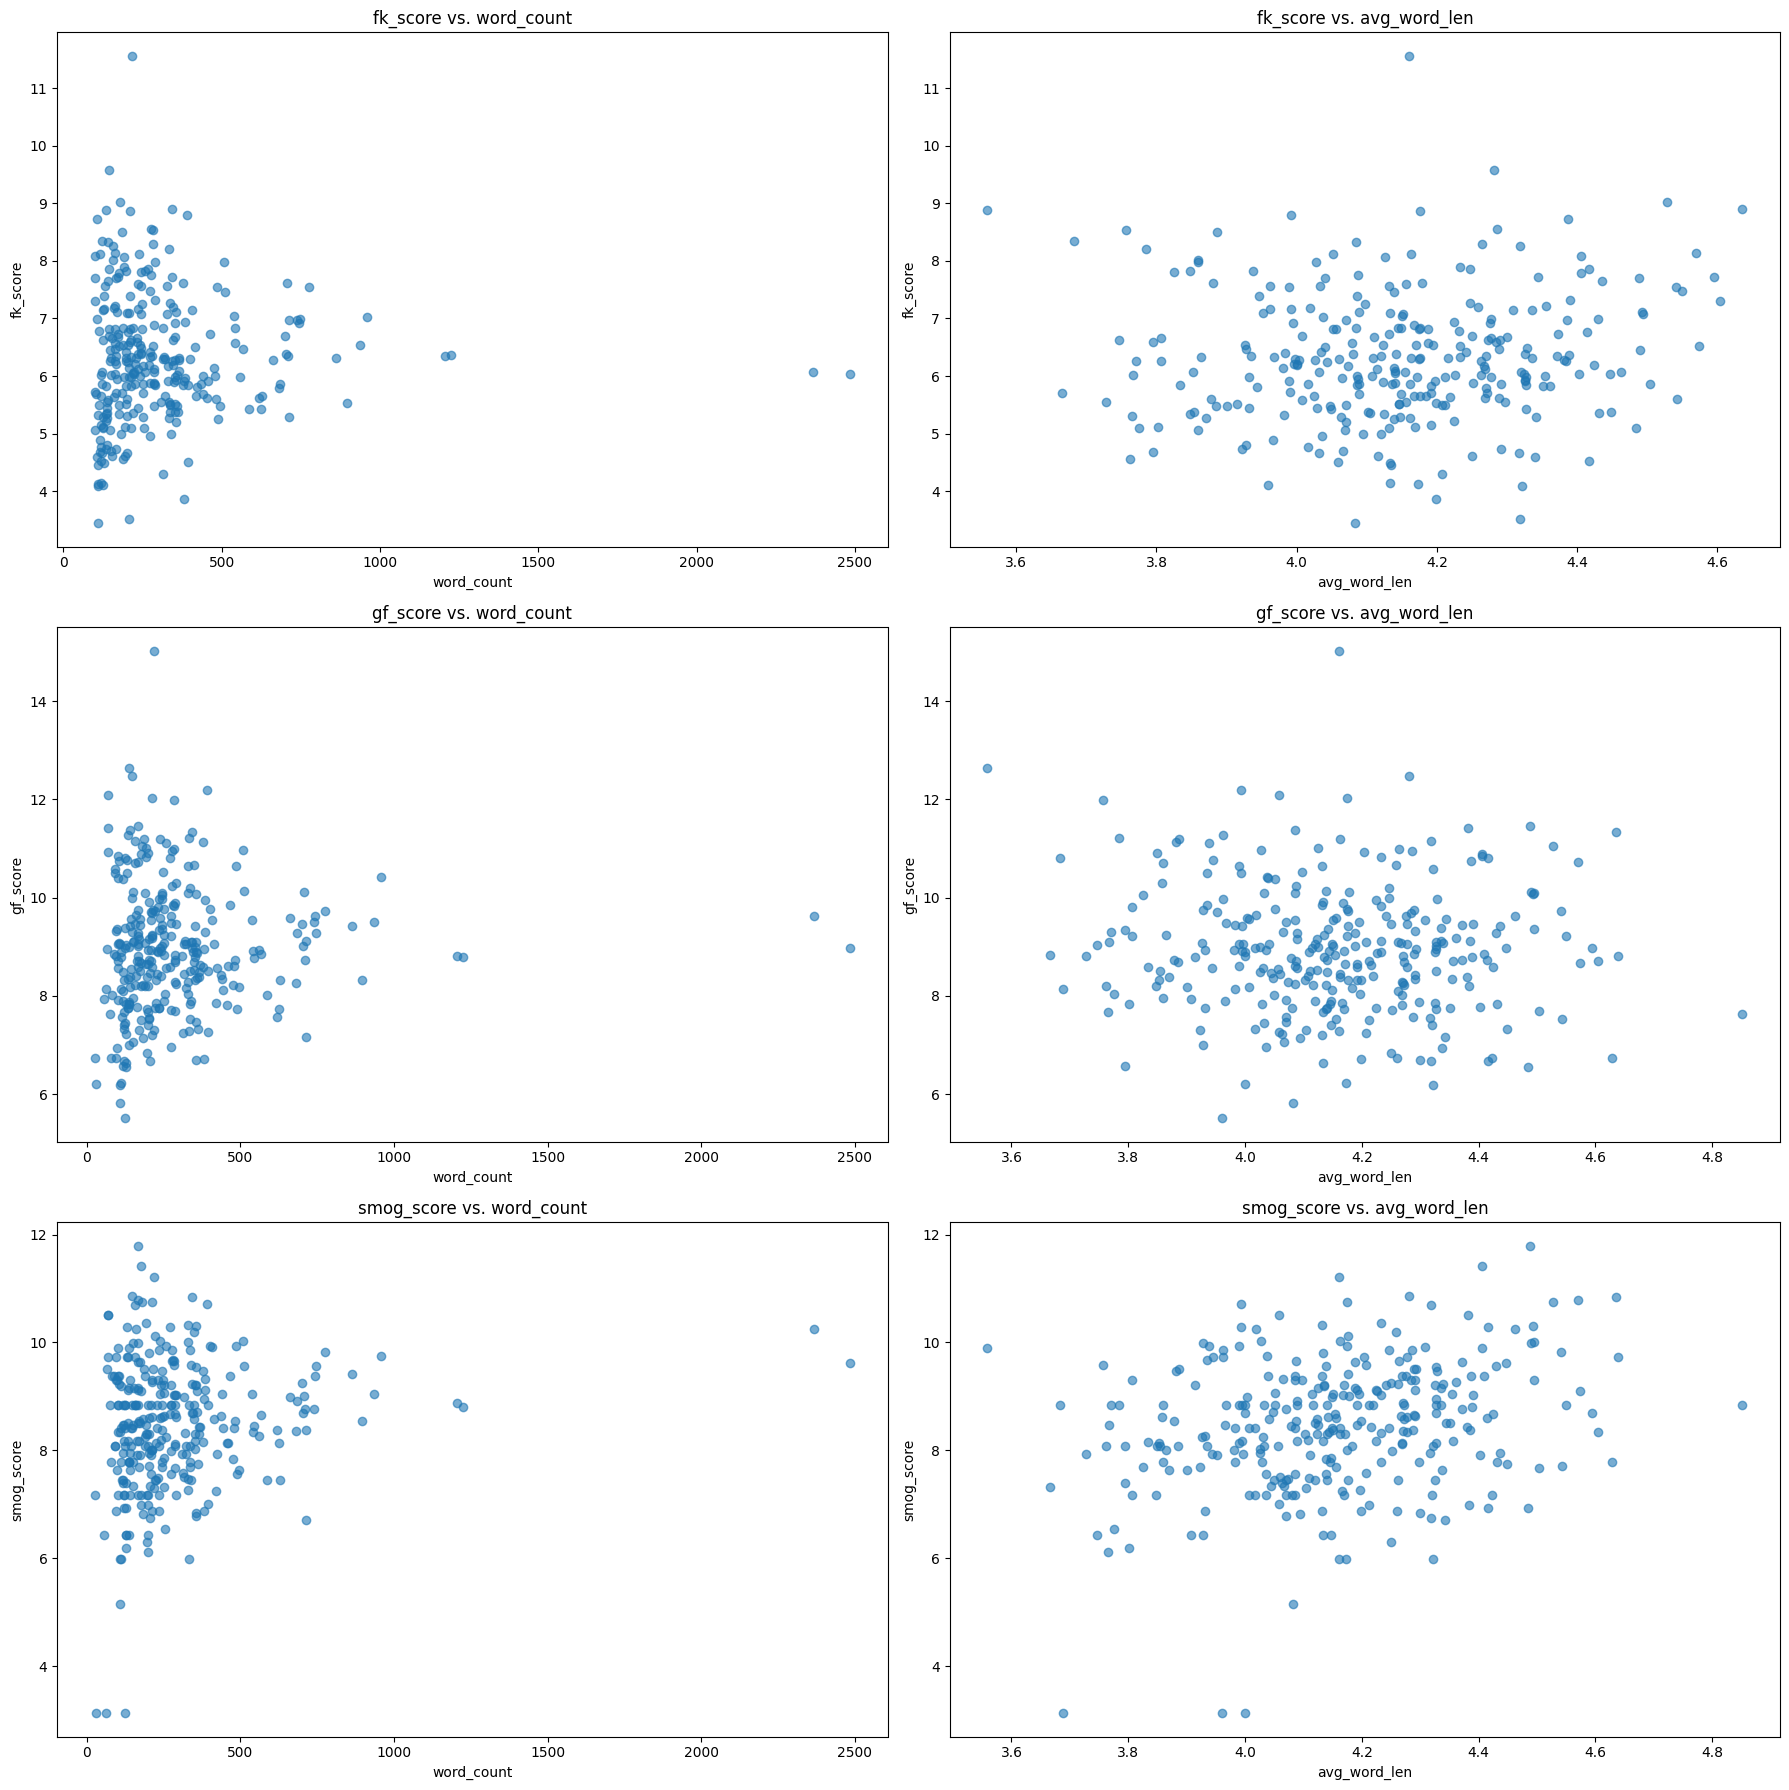

In [31]:
import matplotlib.pyplot as plt

readability_scores = ['fk_score', 'gf_score', 'smog_score']
size_metrics = [
    'word_count',
    'avg_word_len'
]

fig, axes = plt.subplots(
    len(readability_scores),
    len(size_metrics),
    figsize=(18, 18)
)

for i, score in enumerate(readability_scores):
    for j, metric in enumerate(size_metrics):
        axes[i, j].scatter(
            full_psalms[metric],
            full_psalms[score],
            alpha=0.6
        )

        axes[i, j].set_xlabel(metric)
        axes[i, j].set_ylabel(score)
        axes[i, j].set_title(f'{score} vs. {metric}')

plt.tight_layout()
plt.show()

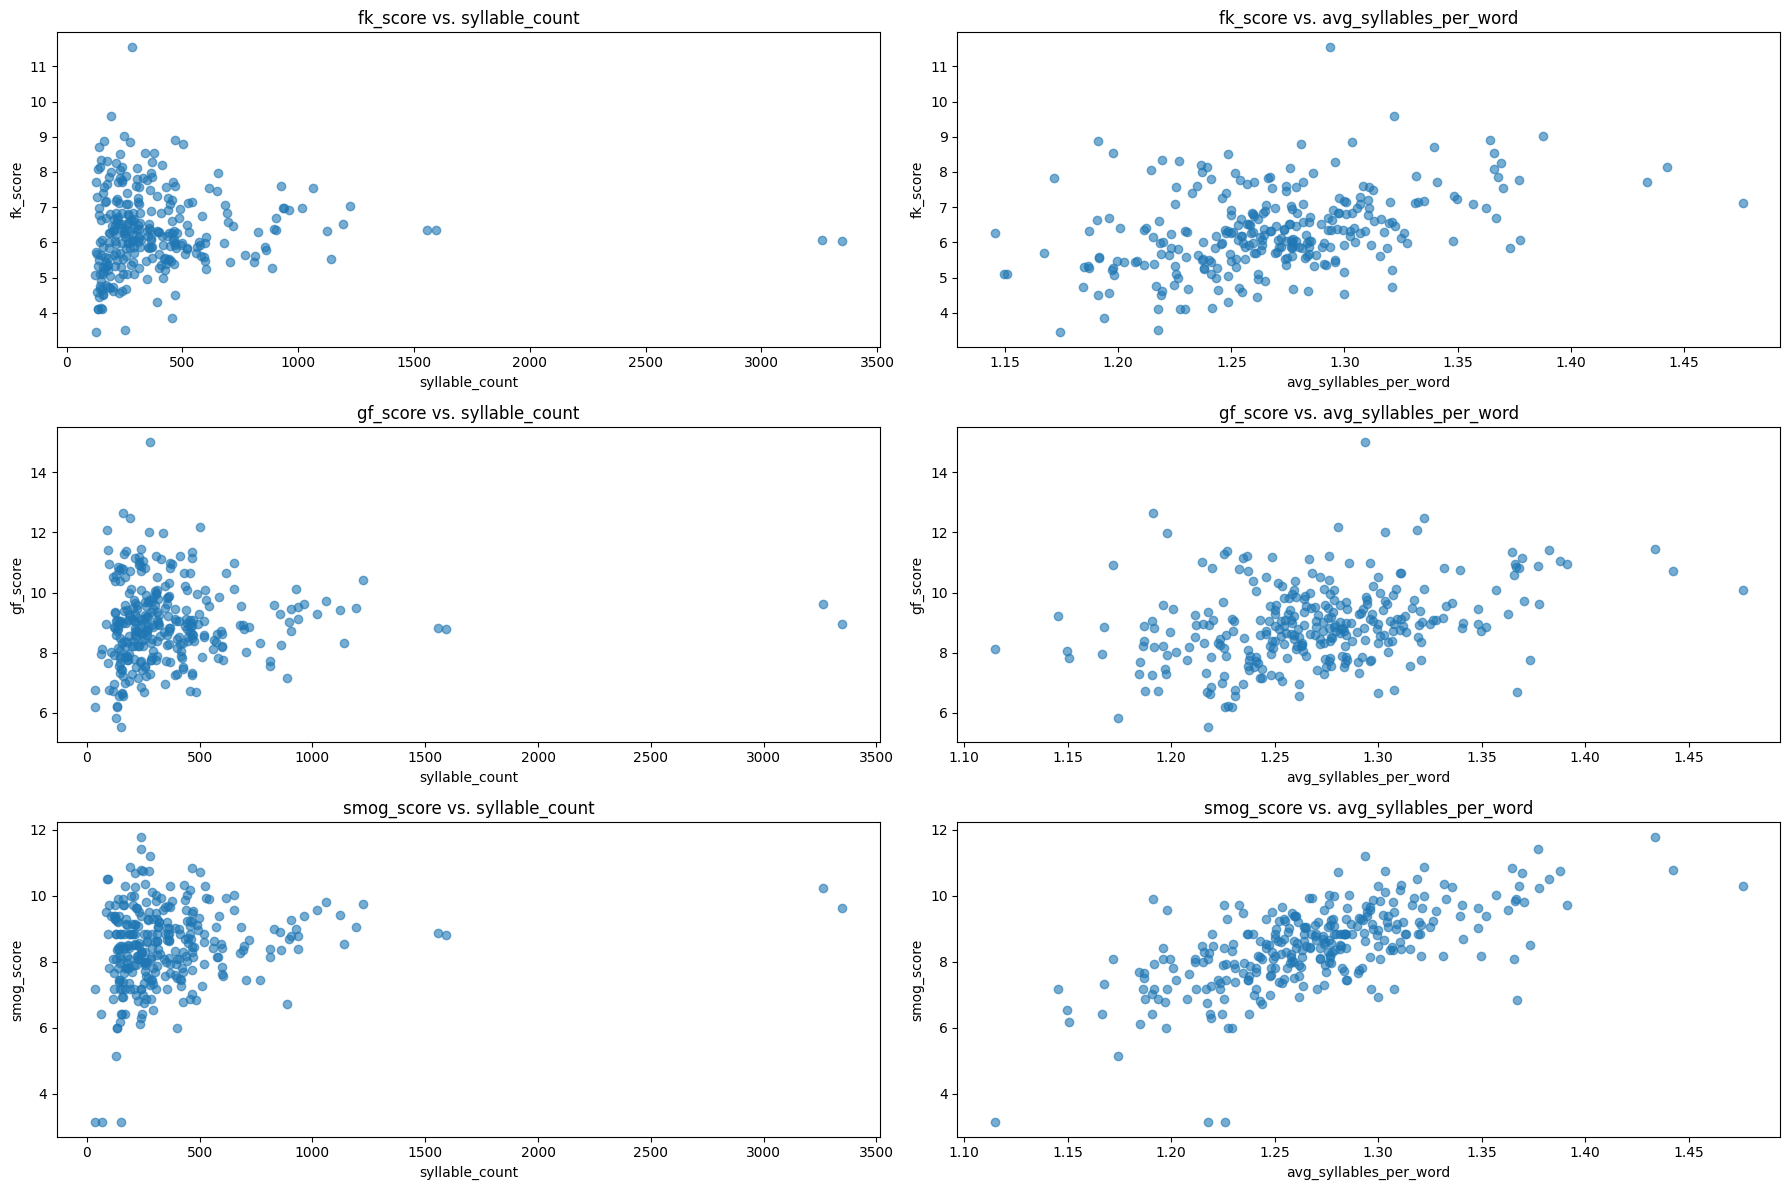

In [32]:
import matplotlib.pyplot as plt

readability_scores = ['fk_score', 'gf_score', 'smog_score']
size_metrics = [
    'syllable_count',
    'avg_syllables_per_word'
]

fig, axes = plt.subplots(
    len(readability_scores),
    len(size_metrics),
    figsize=(18, 12)
)

for i, score in enumerate(readability_scores):
    for j, metric in enumerate(size_metrics):
        axes[i, j].scatter(
            full_psalms[metric],
            full_psalms[score],
            alpha=0.6
        )

        axes[i, j].set_xlabel(metric)
        axes[i, j].set_ylabel(score)
        axes[i, j].set_title(f'{score} vs. {metric}')

plt.tight_layout()
plt.show()

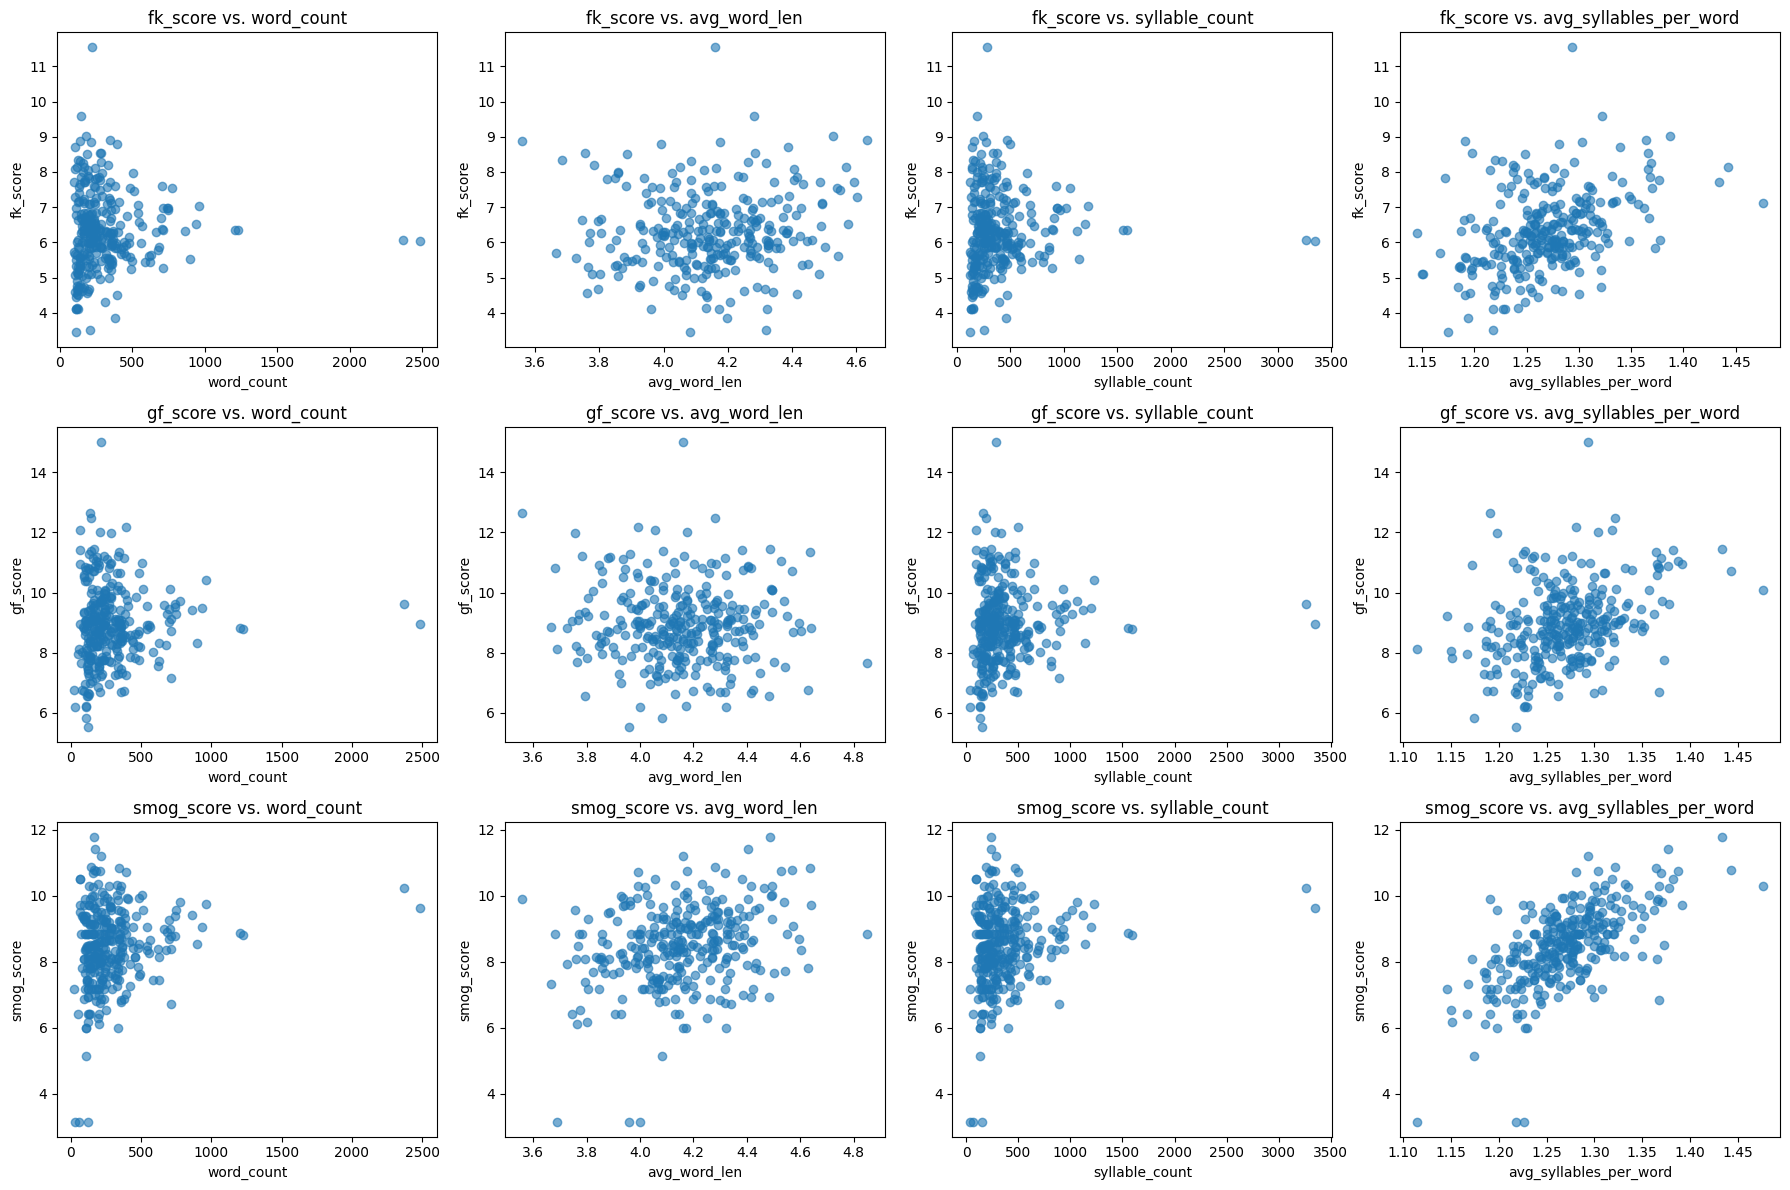

In [33]:
import matplotlib.pyplot as plt

readability_scores = ['fk_score', 'gf_score', 'smog_score']
size_metrics = [
    'word_count',
    'avg_word_len',
    'syllable_count',
    'avg_syllables_per_word'
]

fig, axes = plt.subplots(
    len(readability_scores),
    len(size_metrics),
    figsize=(18, 12)
)

for i, score in enumerate(readability_scores):
    for j, metric in enumerate(size_metrics):
        axes[i, j].scatter(
            full_psalms[metric],
            full_psalms[score],
            alpha=0.6
        )

        axes[i, j].set_xlabel(metric)
        axes[i, j].set_ylabel(score)
        axes[i, j].set_title(f'{score} vs. {metric}')

plt.tight_layout()
plt.show()

## Correlation Matrix


In [34]:
corr_matrix = full_psalms.corr(numeric_only=True)

Correlation Matrix:


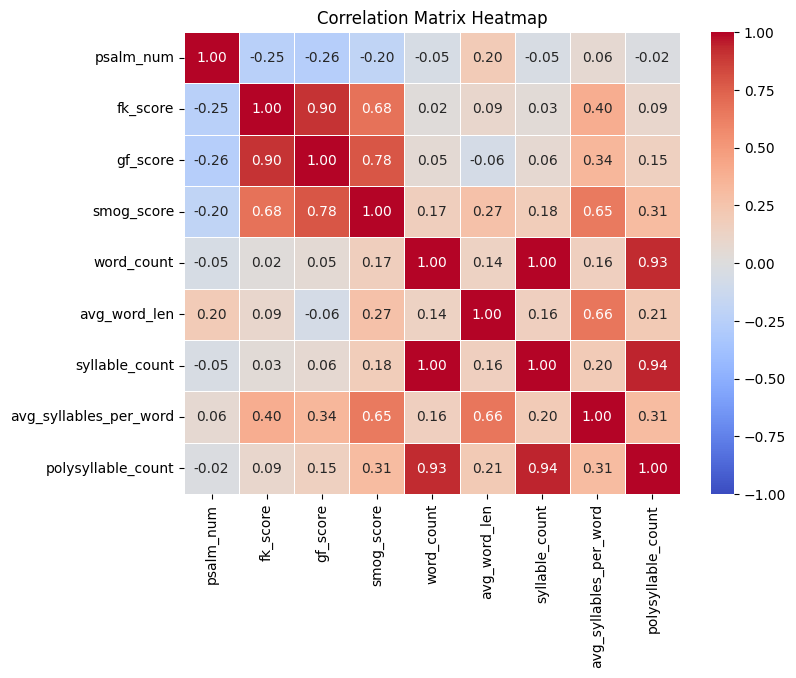

In [35]:
import seaborn as sns

print("Correlation Matrix:")


# 3. Plot the correlation matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the correlation numbers inside the squares
    cmap='coolwarm',     # Color gradient: Blue (Negative), White (Neutral), Red (Positive)
    vmin=-1, vmax=1,     # Force bounds to match the standard correlation range
    fmt=".2f",           # Round the numbers to 2 decimal places
    linewidths=0.5       # Add slight spacing between cells
)

plt.title("Correlation Matrix Heatmap")
plt.show()

In [36]:
corr_matrix

,psalm_num,fk_score,gf_score,smog_score,word_count,avg_word_len,syllable_count,avg_syllables_per_word,polysyllable_count
psalm_num,1.000000,-0.247459,-0.262197,-0.202546,-0.054462,0.195816,-0.045936,0.064346,-0.019330
fk_score,-0.247459,1.000000,0.901062,0.676798,0.019773,0.089886,0.032373,0.397682,0.088275
gf_score,-0.262197,0.901062,1.000000,0.783062,0.053389,-0.062699,0.062815,0.342486,0.150009
smog_score,-0.202546,0.676798,0.783062,1.000000,0.165736,0.266947,0.183834,0.646768,0.307963
word_count,-0.054462,0.019773,0.053389,0.165736,1.000000,0.136197,0.998620,0.164022,0.928828
avg_word_len,0.195816,0.089886,-0.062699,0.266947,0.136197,1.000000,0.159765,0.660207,0.210439
syllable_count,-0.045936,0.032373,0.062815,0.183834,0.998620,0.159765,1.000000,0.198831,0.944214
avg_syllables_per_word,0.064346,0.397682,0.342486,0.646768,0.164022,0.660207,0.198831,1.000000,0.309539
polysyllable_count,-0.019330,0.088275,0.150009,0.307963,0.928828,0.210439,0.944214,0.309539,1.000000


In [37]:
corr_long = (
    corr_matrix.stack()
    .reset_index()
)

corr_long.columns = ['var1', 'var2', 'correlation']


# Remove duplicate pairs (A,B) and (B,A)
corr_long['pair'] = corr_long.apply(
    lambda x: tuple(sorted([x['var1'], x['var2']])),
    axis=1
)
corr_long = corr_long.drop_duplicates('pair')

Original rows: 301
Rows after outlier removal: 245


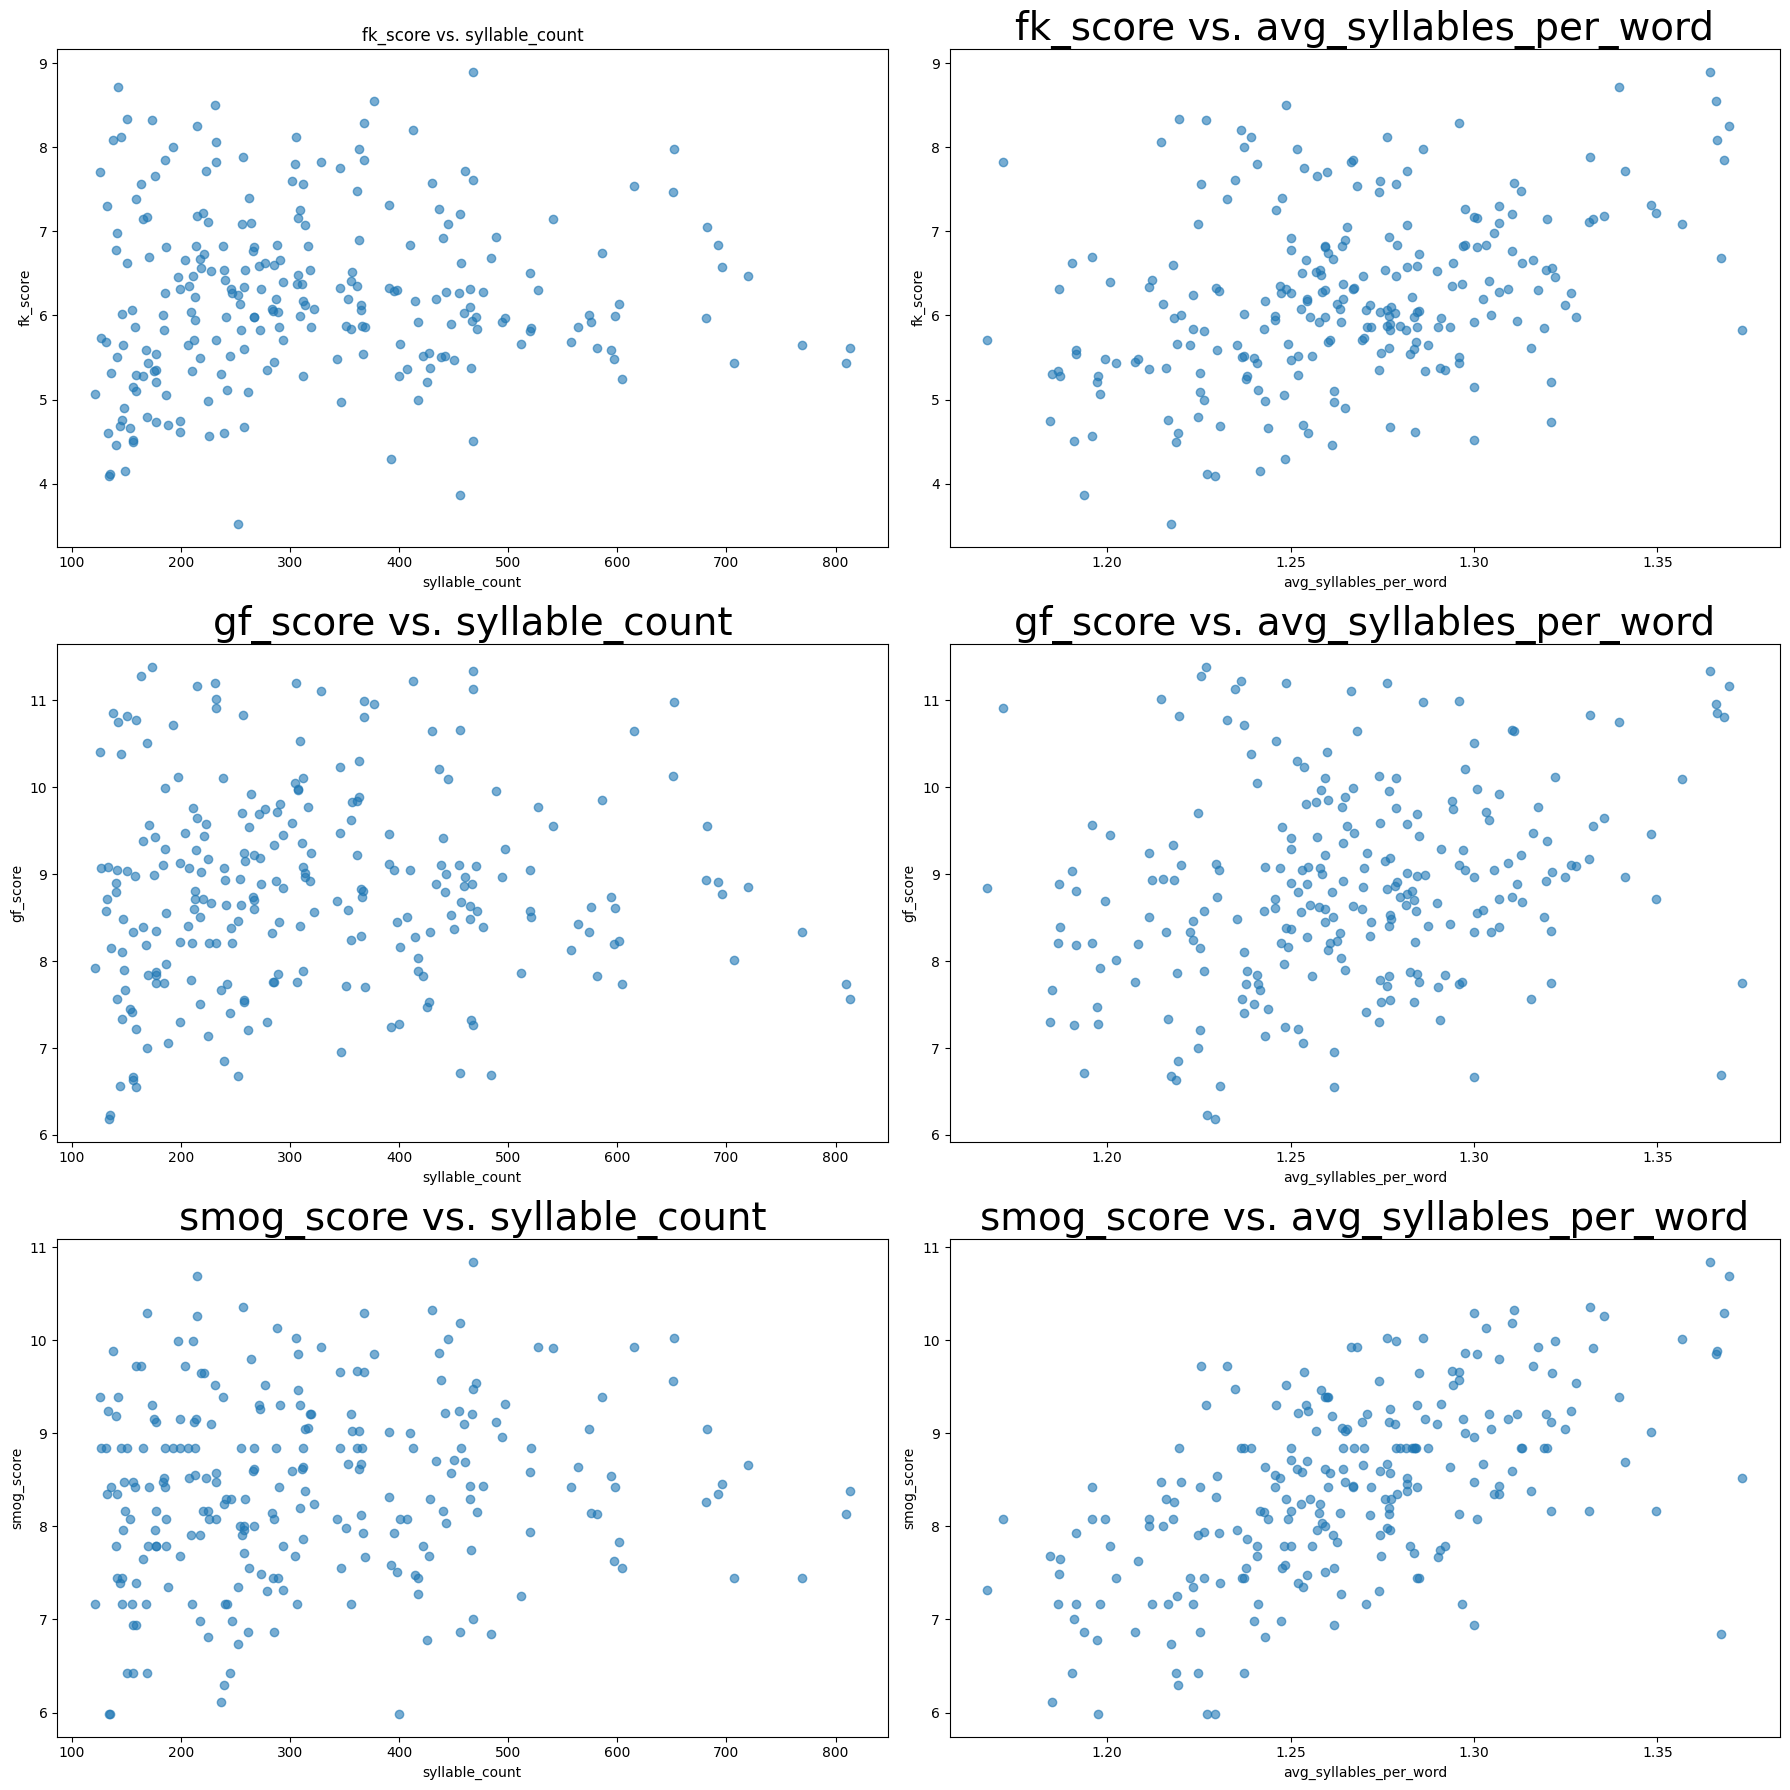

In [38]:
import matplotlib.pyplot as plt

readability_scores = ['fk_score', 'gf_score', 'smog_score']
size_metrics = [
    'syllable_count',
    'avg_syllables_per_word'
]

# Remove outliers using IQR across all variables used in the plots
cols = readability_scores + size_metrics

filtered = full_psalms.copy()

for col in cols:
    Q1 = filtered[col].quantile(0.25)
    Q3 = filtered[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    filtered = filtered[
        (filtered[col] >= lower) &
        (filtered[col] <= upper)
    ]

print(f"Original rows: {len(full_psalms)}")
print(f"Rows after outlier removal: {len(filtered)}")

fig, axes = plt.subplots(
    len(readability_scores),
    len(size_metrics),
    figsize=(18, 18)
)

for i, score in enumerate(readability_scores):
    for j, metric in enumerate(size_metrics):
        axes[i, j].scatter(
            filtered[metric],
            filtered[score],
            alpha=0.6
        )

        axes[i, j].set_xlabel(metric)
        axes[i, j].set_ylabel(score)
        axes[i, j].set_title(f'{score} vs. {metric}')
        plt.rcParams.update({
            'axes.titlesize': 28,
            'axes.labelsize': 24,
            'xtick.labelsize': 16,
            'ytick.labelsize': 16,
            'legend.fontsize': 20
        })

plt.tight_layout()
plt.show()

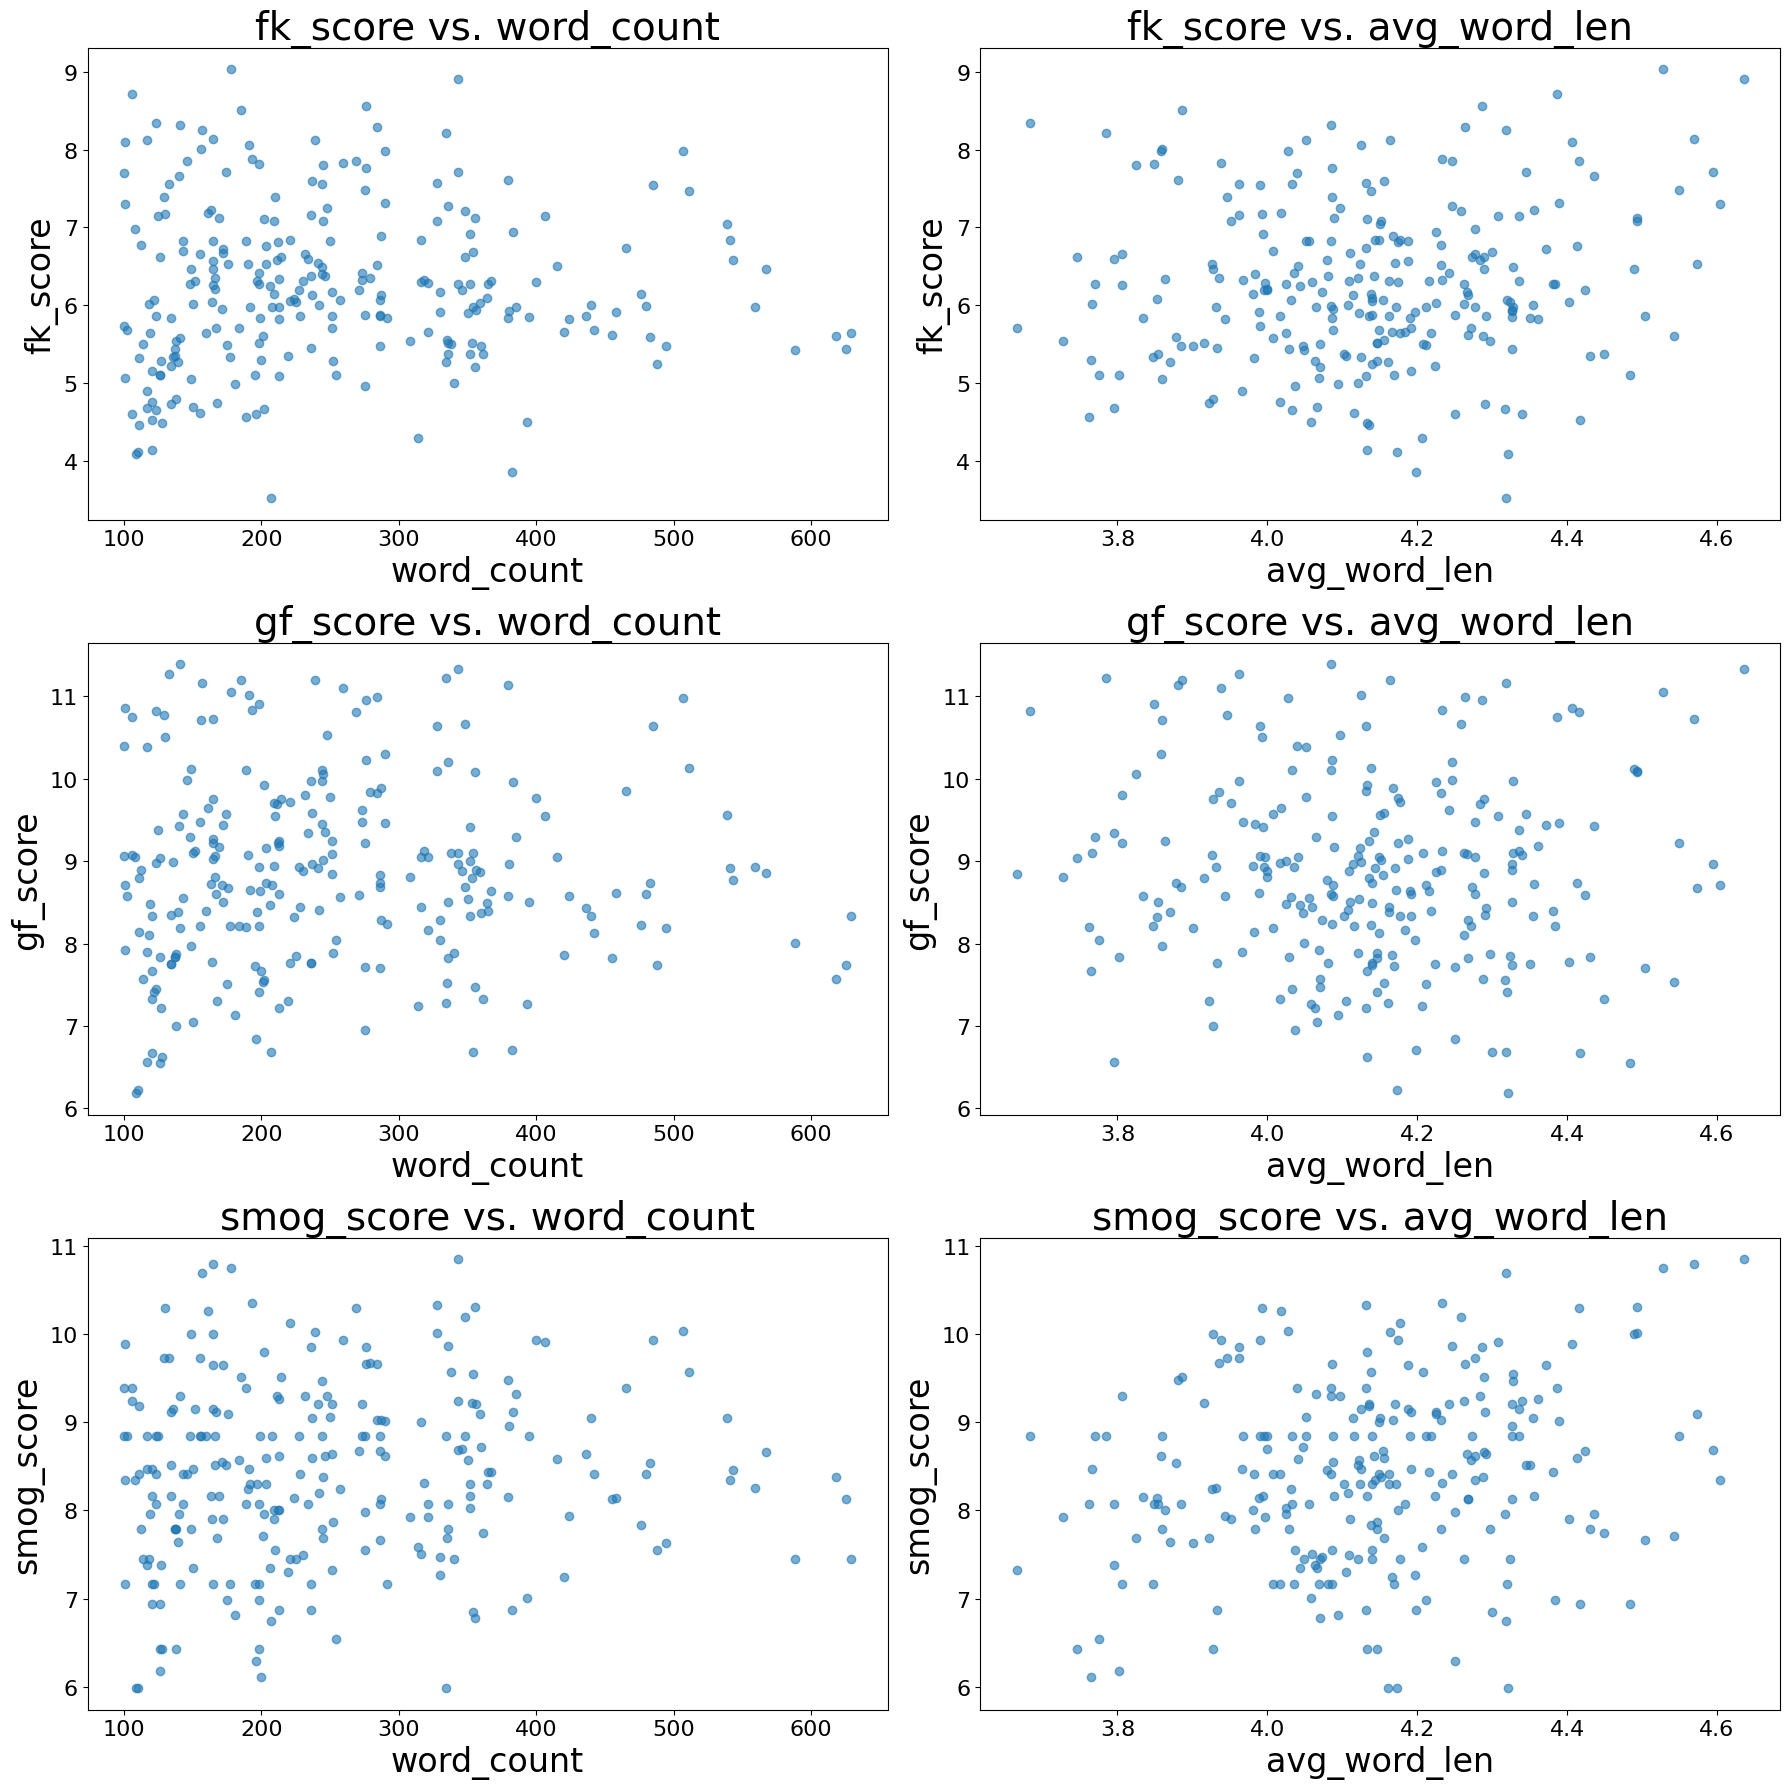

In [39]:
import matplotlib.pyplot as plt

readability_scores = ['fk_score', 'gf_score', 'smog_score']
size_metrics = [
    'word_count',
    'avg_word_len'
]

# Remove outliers using IQR across all variables used in the plots
cols = readability_scores + size_metrics

filtered = full_psalms.copy()

for col in cols:
    Q1 = filtered[col].quantile(0.25)
    Q3 = filtered[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    filtered = filtered[
        (filtered[col] >= lower) &
        (filtered[col] <= upper)
    ]

full_psalms = filtered
fig, axes = plt.subplots(
    len(readability_scores),
    len(size_metrics),
    figsize=(18, 18)
)

for i, score in enumerate(readability_scores):
    for j, metric in enumerate(size_metrics):
        axes[i, j].scatter(
            full_psalms[metric],
            full_psalms[score],
            alpha=0.6
        )

        axes[i, j].set_xlabel(metric)
        axes[i, j].set_ylabel(score)
        axes[i, j].set_title(f'{score} vs. {metric}')

    plt.rcParams.update({
        'axes.titlesize': 28,
        'axes.labelsize': 24,
        'xtick.labelsize': 20,
        'ytick.labelsize': 20,
        'legend.fontsize': 20
    })
plt.tight_layout()
plt.show()

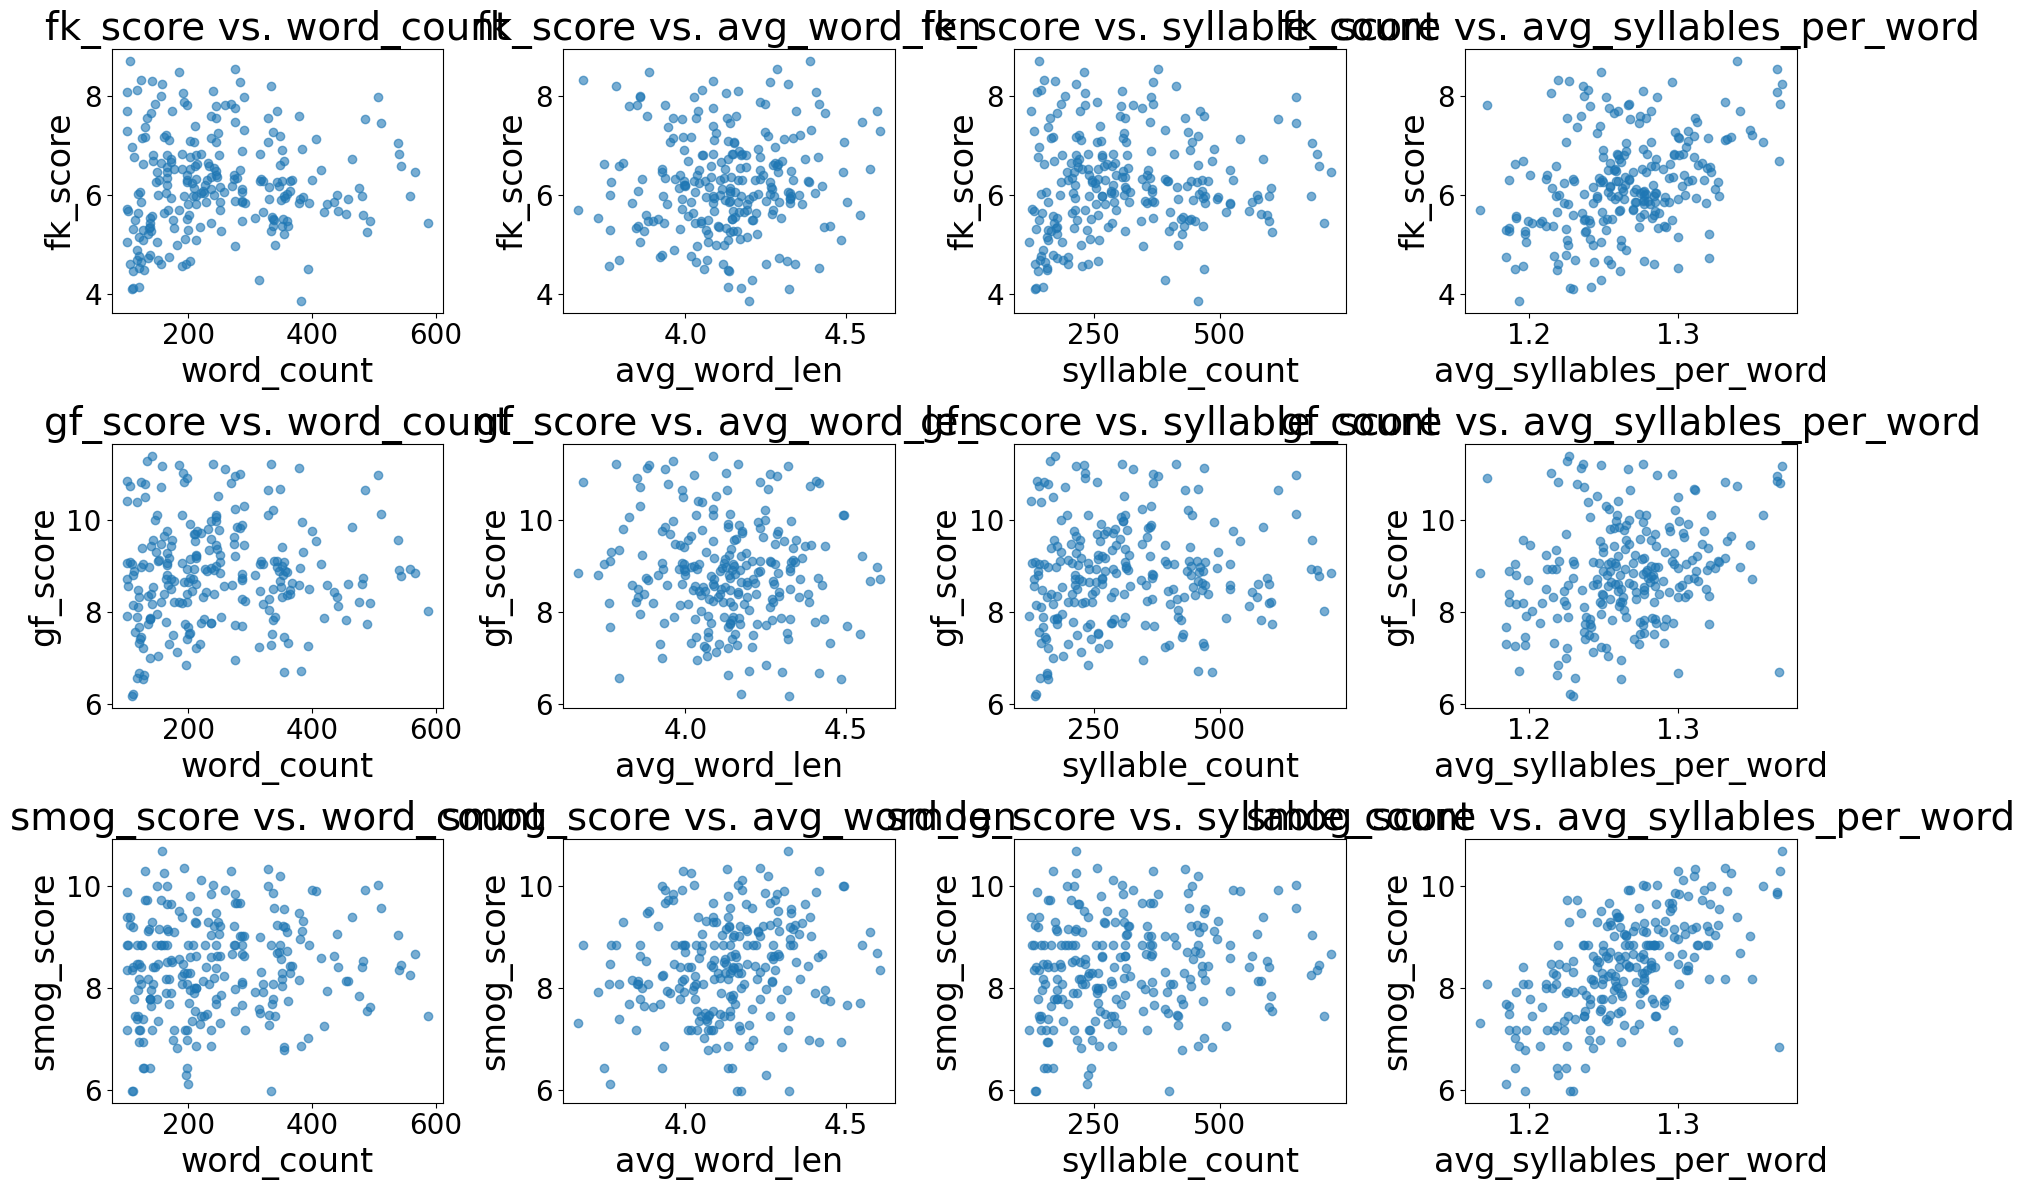

In [40]:
import matplotlib.pyplot as plt

readability_scores = ['fk_score', 'gf_score', 'smog_score']
size_metrics = [
    'word_count',
    'avg_word_len',
    'syllable_count',
    'avg_syllables_per_word'
]

# Remove outliers using IQR across all variables used in the plots
cols = readability_scores + size_metrics

filtered = full_psalms.copy()

for col in cols:
    Q1 = filtered[col].quantile(0.25)
    Q3 = filtered[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    filtered = filtered[
        (filtered[col] >= lower) &
        (filtered[col] <= upper)
    ]

full_psalms = filtered
fig, axes = plt.subplots(
    len(readability_scores),
    len(size_metrics),
    figsize=(18, 12)
)

for i, score in enumerate(readability_scores):
    for j, metric in enumerate(size_metrics):
        axes[i, j].scatter(
            full_psalms[metric],
            full_psalms[score],
            alpha=0.6
        )

        axes[i, j].set_xlabel(metric)
        axes[i, j].set_ylabel(score)
        axes[i, j].set_title(f'{score} vs. {metric}')

    plt.rcParams.update({
        'axes.titlesize': 28,
        'axes.labelsize': 24,
        'xtick.labelsize': 20,
        'ytick.labelsize': 20,
        'legend.fontsize': 20
    })
plt.tight_layout()
plt.show()

In [41]:
corr_long.sort_values(by='correlation')

,var1,var2,correlation,pair
2,psalm_num,gf_score,-0.262197,"(gf_score, psalm_num)"
1,psalm_num,fk_score,-0.247459,"(fk_score, psalm_num)"
3,psalm_num,smog_score,-0.202546,"(psalm_num, smog_score)"
23,gf_score,avg_word_len,-0.062699,"(avg_word_len, gf_score)"
4,psalm_num,word_count,-0.054462,"(psalm_num, word_count)"
6,psalm_num,syllable_count,-0.045936,"(psalm_num, syllable_count)"
8,psalm_num,polysyllable_count,-0.019330,"(polysyllable_count, psalm_num)"
13,fk_score,word_count,0.019773,"(fk_score, word_count)"
15,fk_score,syllable_count,0.032373,"(fk_score, syllable_count)"
22,gf_score,word_count,0.053389,"(gf_score, word_count)"


In [42]:
corr_long[(corr_long['var1'].str.contains('word', na=False)) | (corr_long['var2'].str.contains('word', na=False))]

,var1,var2,correlation,pair
4,psalm_num,word_count,-0.054462,"(psalm_num, word_count)"
5,psalm_num,avg_word_len,0.195816,"(avg_word_len, psalm_num)"
7,psalm_num,avg_syllables_per_word,0.064346,"(avg_syllables_per_word, psalm_num)"
13,fk_score,word_count,0.019773,"(fk_score, word_count)"
14,fk_score,avg_word_len,0.089886,"(avg_word_len, fk_score)"
16,fk_score,avg_syllables_per_word,0.397682,"(avg_syllables_per_word, fk_score)"
22,gf_score,word_count,0.053389,"(gf_score, word_count)"
23,gf_score,avg_word_len,-0.062699,"(avg_word_len, gf_score)"
25,gf_score,avg_syllables_per_word,0.342486,"(avg_syllables_per_word, gf_score)"
31,smog_score,word_count,0.165736,"(smog_score, word_count)"


### Further Oberservations 

- Word Statistics 
    - `word count` & `word length` are not dominatant factors of the reability scores 
        - the biggest correlation is from `smog_score` & `avg_word_len` -> **0.266947**
        
- Syalables 
    - better correlations with `smog_score`, but is part of the calculation of **smog**
    
    
- Readabilty Correlation 
  - FK & GF score  `0.901062`
      - highest correlation
      - both score psalms with very similar readabilty scores
  - FK & SMOG score `0.676798`
      - still indicating that texts with higher FK scores generally also receive higher SMOG scores.
  - GF & SMOG score `0.783062`
      - also strong similarity with scoring between the two readaiblty metrics. 
  - The high correlations suggest that the readability measures provide broadly consistent assessments of Psalm difficulty despite being based on different formulas.
  
#### Odering of the Psalms 
The order of the psalms is not in relation to the simliarity of the Psalms with each other
- i.e. psalm 5 is not pursposefuly more simllar to Psalm 6 than psalm 100